***IMPORTS***

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

***COLLECT AND LABEL DATA***

In [4]:
# Paths
parquet_path = "yellow_tripdata_2025-06.parquet"
lookup_path = "taxi_zone_lookup.csv"

print("Loading trip data...")
df = pd.read_parquet(parquet_path)
print("Rows loaded:", len(df))

print("Loading Taxi Zone Lookup...")
zones = pd.read_csv(lookup_path)
print("Zones loaded:", len(zones))

Loading trip data...
Rows loaded: 4322960
Loading Taxi Zone Lookup...
Zones loaded: 265


In [4]:
# Merge pickup zone info
df = df.merge(
    zones,
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
).rename(columns={
    "Borough": "pickup_borough",
    "Zone": "pickup_zone",
    "service_zone": "pickup_service_zone"
}).drop(columns=["LocationID"])

# Merge dropoff zone info
df = df.merge(
    zones,
    left_on="DOLocationID",
    right_on="LocationID",
    how="left"
).rename(columns={
    "Borough": "dropoff_borough",
    "Zone": "dropoff_zone",
    "service_zone": "dropoff_service_zone"
}).drop(columns=["LocationID"])

df.head()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone
0,1,2025-06-01 00:02:50,2025-06-01 00:39:51,1.0,10.00,1.0,N,138,50,1,...,87.39,2.5,1.75,0.75,Queens,LaGuardia Airport,Airports,Manhattan,Clinton West,Yellow Zone
1,2,2025-06-01 00:11:27,2025-06-01 00:35:35,1.0,3.93,1.0,N,158,237,1,...,36.54,2.5,0.00,0.75,Manhattan,Meatpacking/West Village West,Yellow Zone,Manhattan,Upper East Side South,Yellow Zone
2,1,2025-06-01 00:43:47,2025-06-01 00:49:16,0.0,0.70,1.0,N,230,163,1,...,15.54,2.5,0.00,0.75,Manhattan,Times Sq/Theatre District,Yellow Zone,Manhattan,Midtown North,Yellow Zone
3,1,2025-06-01 00:01:15,2025-06-01 00:42:16,1.0,17.00,2.0,N,132,232,1,...,79.75,2.5,0.00,0.75,Queens,JFK Airport,Airports,Manhattan,Two Bridges/Seward Park,Yellow Zone
4,7,2025-06-01 00:16:32,2025-06-01 00:16:32,1.0,2.22,1.0,N,48,234,1,...,31.50,2.5,0.00,0.75,Manhattan,Clinton East,Yellow Zone,Manhattan,Union Sq,Yellow Zone


***DATA EVALUATION***

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4322960 entries, 0 to 4322959
Data columns (total 26 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [6]:
# missing values
df.isnull().sum()

VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1212946
trip_distance                  0
RatecodeID               1212946
store_and_fwd_flag       1212946
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     1212946
Airport_fee              1212946
cbd_congestion_fee             0
pickup_borough              1961
pickup_zone                 6634
pickup_service_zone         8595
dropoff_borough            19982
dropoff_zone                9250
dropoff_service_zone       29232
dtype: int64

In [7]:
# duplicate rows
df.duplicated().sum()

0

In [8]:
# Datetime validation
(df['tpep_dropoff_datetime'] < df['tpep_pickup_datetime']).sum()

231

In [9]:
# 1.Trips with zero or negative trip_distance
outlier_distance = (df['trip_distance'] <= 0)
print("Trips with zero/negative distance:", outlier_distance.sum())
df[outlier_distance].head()

Trips with zero/negative distance: 134896


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone
158,1,2025-06-01 00:41:47,2025-06-01 01:11:49,1.0,0.0,99.0,N,209,102,1,...,39.00,0.0,0.0,0.00,Manhattan,Seaport,Yellow Zone,Queens,Glendale,Boro Zone
200,2,2025-06-01 00:08:56,2025-06-01 00:33:46,1.0,0.0,1.0,N,68,238,1,...,30.66,2.5,0.0,0.75,Manhattan,East Chelsea,Yellow Zone,Manhattan,Upper West Side North,Yellow Zone
264,2,2025-06-01 00:30:21,2025-06-01 00:30:28,1.0,0.0,2.0,N,239,239,2,...,-74.00,-2.5,0.0,0.00,Manhattan,Upper West Side South,Yellow Zone,Manhattan,Upper West Side South,Yellow Zone
265,2,2025-06-01 00:30:21,2025-06-01 00:30:28,1.0,0.0,2.0,N,239,239,2,...,74.00,2.5,0.0,0.00,Manhattan,Upper West Side South,Yellow Zone,Manhattan,Upper West Side South,Yellow Zone
347,1,2025-06-01 00:08:38,2025-06-01 00:21:12,1.0,0.0,1.0,N,49,232,1,...,23.00,0.0,0.0,0.00,Brooklyn,Clinton Hill,Boro Zone,Manhattan,Two Bridges/Seward Park,Yellow Zone


In [10]:
# 2.Trips with negative or zero fare amounts
outlier_fare = (df['fare_amount'] <= 0)
print("Trips with negative/zero fare:", outlier_fare.sum())
df[outlier_fare].head()

Trips with negative/zero fare: 277527


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone
80,2,2025-06-01 00:49:34,2025-06-01 00:50:44,1.0,0.14,1.0,N,68,68,4,...,-9.45,-2.5,0.0,-0.75,Manhattan,East Chelsea,Yellow Zone,Manhattan,East Chelsea,Yellow Zone
224,2,2025-06-01 00:39:48,2025-06-01 00:44:40,4.0,0.83,1.0,N,100,170,4,...,-12.95,-2.5,0.0,-0.75,Manhattan,Garment District,Yellow Zone,Manhattan,Murray Hill,Yellow Zone
264,2,2025-06-01 00:30:21,2025-06-01 00:30:28,1.0,0.00,2.0,N,239,239,2,...,-74.00,-2.5,0.0,0.00,Manhattan,Upper West Side South,Yellow Zone,Manhattan,Upper West Side South,Yellow Zone
331,2,2025-06-01 00:18:11,2025-06-01 00:18:21,1.0,0.02,1.0,N,113,113,4,...,-8.75,-2.5,0.0,-0.75,Manhattan,Greenwich Village North,Yellow Zone,Manhattan,Greenwich Village North,Yellow Zone
458,2,2025-06-01 00:28:48,2025-06-01 00:43:28,1.0,3.17,1.0,N,142,75,4,...,-22.70,-2.5,0.0,0.00,Manhattan,Lincoln Square East,Yellow Zone,Manhattan,East Harlem South,Boro Zone


In [11]:
# 3. Trips with extremely long trip times (> 3 hours)
# Calculate trip duration in minutes
df['trip_minutes'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
outlier_duration = (df['trip_minutes'] > 180)
print("Trips longer than 3 hours:", outlier_duration.sum())
df[outlier_duration].head()

Trips longer than 3 hours: 1380


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone,trip_minutes
1490,2,2025-06-01 00:59:55,2025-06-01 15:45:43,1.0,17.28,1.0,N,170,132,2,...,2.5,0.00,0.75,Manhattan,Murray Hill,Yellow Zone,Queens,JFK Airport,Airports,885.80
2533,2,2025-06-01 00:35:51,2025-06-02 00:29:48,1.0,4.72,1.0,N,246,262,1,...,2.5,0.00,0.75,Manhattan,West Chelsea/Hudson Yards,Yellow Zone,Manhattan,Yorkville East,Yellow Zone,1433.95
3505,2,2025-06-01 00:37:02,2025-06-01 11:25:26,1.0,2.15,1.0,N,90,193,2,...,2.5,0.00,0.75,Manhattan,Flatiron,Yellow Zone,Queens,Queensbridge/Ravenswood,Boro Zone,648.40
4813,2,2025-06-01 00:02:17,2025-06-02 00:00:59,1.0,18.48,2.0,N,132,142,1,...,2.5,1.75,0.75,Queens,JFK Airport,Airports,Manhattan,Lincoln Square East,Yellow Zone,1438.70
5095,2,2025-06-01 01:08:03,2025-06-02 00:53:06,1.0,1.58,1.0,N,48,239,1,...,2.5,0.00,0.75,Manhattan,Clinton East,Yellow Zone,Manhattan,Upper West Side South,Yellow Zone,1425.05


***DATA CLEANING***

In [12]:
df = df.drop_duplicates()

In [13]:
df = df[
    (df['trip_distance'] > 0) &
    (df['fare_amount'] > 0) &
    (df['trip_minutes'] > 0) &
    (df['trip_minutes'] <= 180)
]

df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone,trip_minutes
0,1,2025-06-01 00:02:50,2025-06-01 00:39:51,1.0,10.00,1.0,N,138,50,1,...,2.5,1.75,0.75,Queens,LaGuardia Airport,Airports,Manhattan,Clinton West,Yellow Zone,37.016667
1,2,2025-06-01 00:11:27,2025-06-01 00:35:35,1.0,3.93,1.0,N,158,237,1,...,2.5,0.00,0.75,Manhattan,Meatpacking/West Village West,Yellow Zone,Manhattan,Upper East Side South,Yellow Zone,24.133333
2,1,2025-06-01 00:43:47,2025-06-01 00:49:16,0.0,0.70,1.0,N,230,163,1,...,2.5,0.00,0.75,Manhattan,Times Sq/Theatre District,Yellow Zone,Manhattan,Midtown North,Yellow Zone,5.483333
3,1,2025-06-01 00:01:15,2025-06-01 00:42:16,1.0,17.00,2.0,N,132,232,1,...,2.5,0.00,0.75,Queens,JFK Airport,Airports,Manhattan,Two Bridges/Seward Park,Yellow Zone,41.016667
5,1,2025-06-01 00:05:23,2025-06-01 00:16:57,0.0,0.90,1.0,N,164,90,2,...,2.5,0.00,0.75,Manhattan,Midtown South,Yellow Zone,Manhattan,Flatiron,Yellow Zone,11.566667


In [14]:
#missing or inconsistent passenger counts
df['passenger_count'] = df['passenger_count'].replace(0, 1)

***FEATURE ENGINEERING***

In [15]:
#time based features
df['hour'] = df['tpep_pickup_datetime'].dt.hour
df['day_of_week'] = df['tpep_pickup_datetime'].dt.weekday
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['month'] = df['tpep_pickup_datetime'].dt.month

In [16]:
#trip based features
df['speed_mph'] = df['trip_distance'] / (df['trip_minutes'] / 60)

In [17]:
#Demand aggregation
demand = df.groupby(['PULocationID', 'hour', 'day_of_week']).size().reset_index(name='demand')

In [18]:
#statistical features 
demand['rolling_mean'] = demand.groupby("PULocationID")["demand"].transform(lambda x: x.rolling(3, min_periods=1).mean())

In [19]:
#Location features 
demand = demand.merge(zones[['LocationID','Borough']], left_on="PULocationID", right_on="LocationID")

***TRAIN AND TEST THE MODEL***

*Random Forest*

In [20]:
#Train/Validation split 
X = demand[['PULocationID','hour','day_of_week','rolling_mean']]
X = pd.get_dummies(X, columns=['PULocationID'])

y = demand['demand']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
#Model selection and Training 
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,20
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
#Model evaluation 
y_pred = model.predict(X_test)

In [23]:
mae_RF = mean_absolute_error(y_test, y_pred)
mae_RF

13.033929770746694

***MODEL TUNING***

In [26]:
params = {
    "n_estimators": [200, 300, 500],
    "max_depth": [10, 15, 20],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    params,
    cv=3,
    scoring="neg_mean_squared_error"
)

grid.fit(X_train, y_train)

grid.best_params_

{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 500}

In [27]:
best_model = grid.best_estimator_
print(best_model)

RandomForestRegressor(max_depth=20, n_estimators=500, n_jobs=-1,
                      random_state=42)


In [28]:
best_rf_pred = best_model.predict(X_test)
tuned_RF = mean_absolute_error(y_test, best_rf_pred)
print(f"Tuned RF MAE: {tuned_RF}")

Tuned RF MAE: 12.815214003961398


*XGBOOST MODEL*

In [29]:
# Baseline XGBoost model
xgb_baseline = XGBRegressor(
    n_estimators=400,
    max_depth=7,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9
)

# Train
xgb_baseline.fit(X_train, y_train)

# Predict
y_pred_baseline = xgb_baseline.predict(X_test)

# Evaluate
mae_XG = mean_absolute_error(y_test, y_pred_baseline)
print("Baseline XGBoost MAE:", mae_XG)

Baseline XGBoost MAE: 10.734234809875488


In [30]:
# Parameters to tune
params = {
    'n_estimators': [300, 500, 700],
    'max_depth': [6, 8, 10],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# GridSearchCV
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)
grid = GridSearchCV(xgb_model, params, cv=3, scoring='neg_mean_squared_error', verbose=1, n_jobs=-1)

grid.fit(X_train, y_train)

# Best model
best_xgb = grid.best_estimator_
print("Best XGBoost params:", grid.best_params_)

# Predict & evaluate
y_pred_xgb = best_xgb.predict(X_test)
tuned_XG = mean_absolute_error(y_test, y_pred_xgb)
print("Tuned XGBoost MAE:", tuned_XG)


Fitting 3 folds for each of 162 candidates, totalling 486 fits
Best XGBoost params: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 700, 'subsample': 0.9}
Tuned XGBoost RMSE: 10.796279907226562


*Multilayer Perceptron*

In [31]:
mlp_baseline = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    learning_rate_init=0.001,
    max_iter=100,
    random_state=42
)

mlp_baseline.fit(X_train, y_train)

y_pred_baseline = mlp_baseline.predict(X_test)
mae_MLP = mean_absolute_error(y_test, y_pred_baseline)
print("Baseline MLP MAE:", mae_MLP)


Baseline MLP MAE: 17.750306159595038


C:\Users\thota\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


In [32]:
param_grid = {
    'hidden_layer_sizes': [(64,32), (128,64,32)],
    'learning_rate_init': [0.001, 0.01],
    'alpha': [0.0001, 0.001],  # L2 regularization
    'batch_size': [256, 512]
}

mlp_model = MLPRegressor(max_iter=200, random_state=42)

grid = GridSearchCV(mlp_model, param_grid, scoring='neg_mean_absolute_error', cv=3, n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

best_mlp = grid.best_estimator_
print("Best MLP params:", grid.best_params_)

y_pred_mlp = best_mlp.predict(X_test)
tuned_MLP = mean_absolute_error(y_test, y_pred_mlp)
print("Tuned MLP MAE:", tuned_MLP)


Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best MLP params: {'alpha': 0.0001, 'batch_size': 256, 'hidden_layer_sizes': (128, 64, 32), 'learning_rate_init': 0.001}
Tuned MLP MAE: 14.587525918034618


In [33]:
# Collect results
results = pd.DataFrame({
    'Model': ['Random Forest', 'Random Forest (Tuned)',
              'XGBoost', 'XGBoost (Tuned)',
              'MLP', 'MLP (Tuned)'],
    'MAE': [mae_RF, tuned_RF,
            mae_XG, tuned_XG,
            mae_MLP, tuned_MLP]
})

# Display summary table
results


,Model,MAE
0,Random Forest,13.033930
1,Random Forest (Tuned),12.815214
2,XGBoost,10.734235
3,XGBoost (Tuned),10.796280
4,MLP,17.750306
5,MLP (Tuned),14.587526


***Model Deployment (Predicting Demand & Finding Hotspots)***

In [34]:
def predict_demand(model, input_df):
    input_encoded = pd.get_dummies(input_df, columns=['PULocationID'])
    # Ensure all columns from training exist
    input_encoded = input_encoded.reindex(columns=X_train.columns, fill_value=0)
    predictions = model.predict(input_encoded)
    input_df['predicted_demand'] = predictions
    return input_df


In [73]:
# 1.Prepare all zones for prediction
all_zones = pd.DataFrame({
    'PULocationID': demand['PULocationID'].unique()
})
all_zones['hour'] = 18         # e.g., 6 PM
all_zones['day_of_week'] = 4   # e.g., Friday

# Merge historical rolling mean
all_zones = all_zones.merge(
    demand[['PULocationID','hour','day_of_week','rolling_mean']],
    on=['PULocationID','hour','day_of_week'],
    how='left'
)
all_zones['rolling_mean'] = all_zones['rolling_mean'].fillna(demand['rolling_mean'].mean())

# 2.One-hot encode PULocationID
all_zones_enc = pd.get_dummies(all_zones, columns=['PULocationID'])

# Ensure all columns from training exist
for col in X_train.columns:
    if col not in all_zones_enc.columns:
        all_zones_enc[col] = 0

# Keep only the training columns in correct order
all_zones_enc = all_zones_enc[X_train.columns]

# 3.Predict demand using each model
def predict_demand_clean(model, input_df, original_df):
    """
    Predict demand and return a DataFrame with PULocationID and predicted demand.
    """
    predictions = model.predict(input_df)
    return pd.DataFrame({
        'PULocationID': original_df['PULocationID'],
        'predicted_demand': predictions
    })

rf_preds = predict_demand_clean(best_model, all_zones_enc, all_zones)
xgb_preds = predict_demand_clean(best_xgb, all_zones_enc, all_zones)
mlp_preds = predict_demand_clean(best_mlp, all_zones_enc, all_zones)

# 4.Merge zone names for readability
rf_preds = rf_preds.merge(zones[['LocationID','Zone']], left_on='PULocationID', right_on='LocationID').drop(columns=['LocationID'])
xgb_preds = xgb_preds.merge(zones[['LocationID','Zone']], left_on='PULocationID', right_on='LocationID').drop(columns=['LocationID'])
mlp_preds = mlp_preds.merge(zones[['LocationID','Zone']], left_on='PULocationID', right_on='LocationID').drop(columns=['LocationID'])

# 5.Display top 10 hotspots for each model
print("RF Top Hotspots:\n", rf_preds.sort_values('predicted_demand', ascending=False).head(10))
print("\nXGBoost Top Hotspots:\n", xgb_preds.sort_values('predicted_demand', ascending=False).head(10))
print("\nMLP Top Hotspots:\n", mlp_preds.sort_values('predicted_demand', ascending=False).head(10))


RF Top Hotspots:
      PULocationID  predicted_demand                          Zone
153           161       1602.152000                Midtown Center
229           237       1544.741429         Upper East Side South
228           236       1348.425016         Upper East Side North
154           162       1250.280600                  Midtown East
124           132       1165.276000                   JFK Airport
178           186       1099.416630  Penn Station/Madison Sq West
155           163       1010.826144                 Midtown North
162           170        998.558150                   Murray Hill
222           230        986.195137     Times Sq/Theatre District
134           142        945.924420           Lincoln Square East

XGBoost Top Hotspots:
      PULocationID  predicted_demand                          Zone
229           237       1473.187988         Upper East Side South
153           161       1369.538208                Midtown Center
228           236       1315.06176

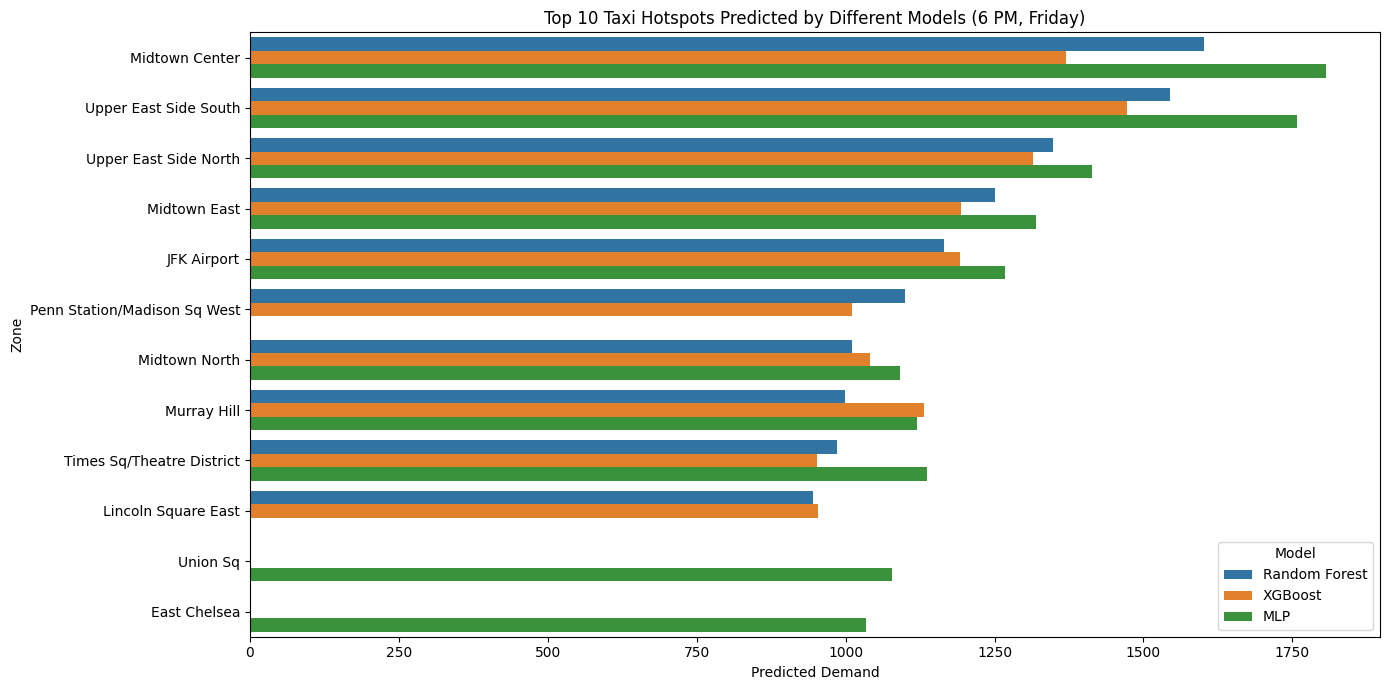

In [75]:
# 1.Get top 10 hotspots for each model
top_n = 10
rf_top = rf_preds.sort_values('predicted_demand', ascending=False).head(top_n)
xgb_top = xgb_preds.sort_values('predicted_demand', ascending=False).head(top_n)
mlp_top = mlp_preds.sort_values('predicted_demand', ascending=False).head(top_n)

# 2.Prepare for plotting
# Add a 'Model' column to differentiate
rf_top['Model'] = 'Random Forest'
xgb_top['Model'] = 'XGBoost'
mlp_top['Model'] = 'MLP'

# Concatenate all data
plot_df = pd.concat([rf_top, xgb_top, mlp_top], ignore_index=True)

# 3.Plot using Seaborn
plt.figure(figsize=(14, 7))
sns.barplot(
    data=plot_df,
    x='predicted_demand',
    y='Zone',
    hue='Model',
    dodge=True
)
plt.title(f"Top {top_n} Taxi Hotspots Predicted by Different Models (6 PM, Friday)")
plt.xlabel("Predicted Demand")
plt.ylabel("Zone")
plt.legend(title='Model')
plt.tight_layout()
plt.show()

In [ ]:
# Compute full metrics (MAE, RMSE, R2) for each tuned model on the test set
rf_mae = mean_absolute_error(y_test, best_rf_pred)
rf_rmse = mean_squared_error(y_test, best_rf_pred, squared=False)
rf_r2 = r2_score(y_test, best_rf_pred)

xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_rmse = mean_squared_error(y_test, y_pred_xgb, squared=False)
xgb_r2 = r2_score(y_test, y_pred_xgb)

mlp_mae = mean_absolute_error(y_test, y_pred_mlp)
mlp_rmse = mean_squared_error(y_test, y_pred_mlp, squared=False)
mlp_r2 = r2_score(y_test, y_pred_mlp)

In [84]:
# Create a DataFrame with the metrics
metrics_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'MLP'],
    'MAE': [rf_mae, xgb_mae, mlp_mae],
    'RMSE': [rf_rmse, xgb_rmse, mlp_rmse],
    'R2 Score': [rf_r2, xgb_r2, mlp_r2]
})

# Display the table
print(metrics_df)


           Model        MAE       RMSE  R2 Score
0  Random Forest  12.815214  42.137801  0.972414
1        XGBoost  10.796280  29.540252  0.986443
2            MLP  14.587526  43.222246  0.970975


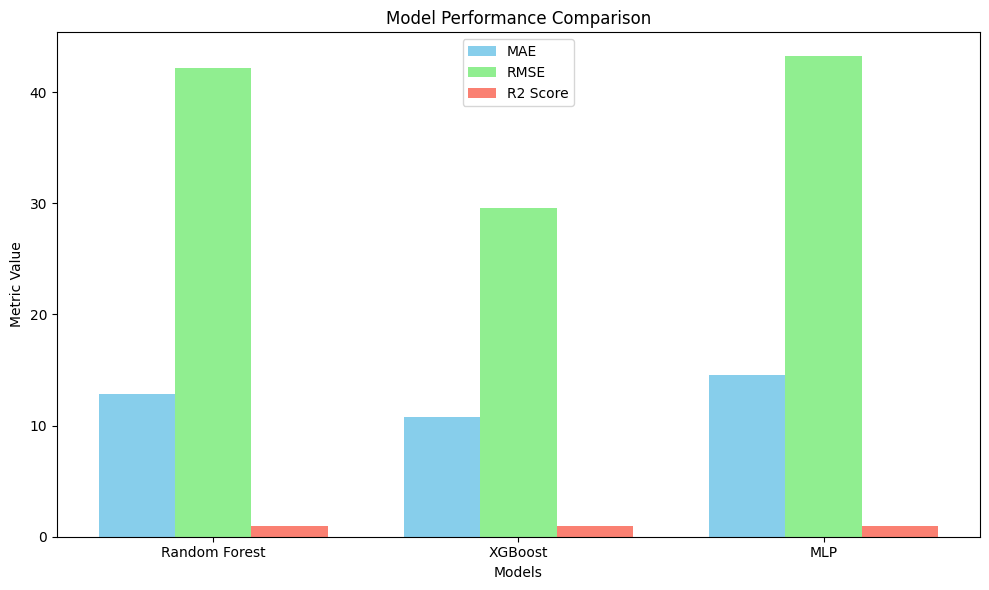

In [85]:
# Metrics data
models = ['Random Forest', 'XGBoost', 'MLP']
mae = [rf_mae, xgb_mae, mlp_mae]
rmse = [rf_rmse, xgb_rmse, mlp_rmse]
r2 = [rf_r2, xgb_r2, mlp_r2]

# X-axis positions
x = np.arange(len(models))
width = 0.25

# Create bar chart
plt.figure(figsize=(10,6))
plt.bar(x - width, mae, width, label='MAE', color='skyblue')
plt.bar(x, rmse, width, label='RMSE', color='lightgreen')
plt.bar(x + width, r2, width, label='R2 Score', color='salmon')

# Labels and title
plt.xlabel('Models')
plt.ylabel('Metric Value')
plt.title('Model Performance Comparison')
plt.xticks(x, models)
plt.legend()
plt.tight_layout()
plt.show()

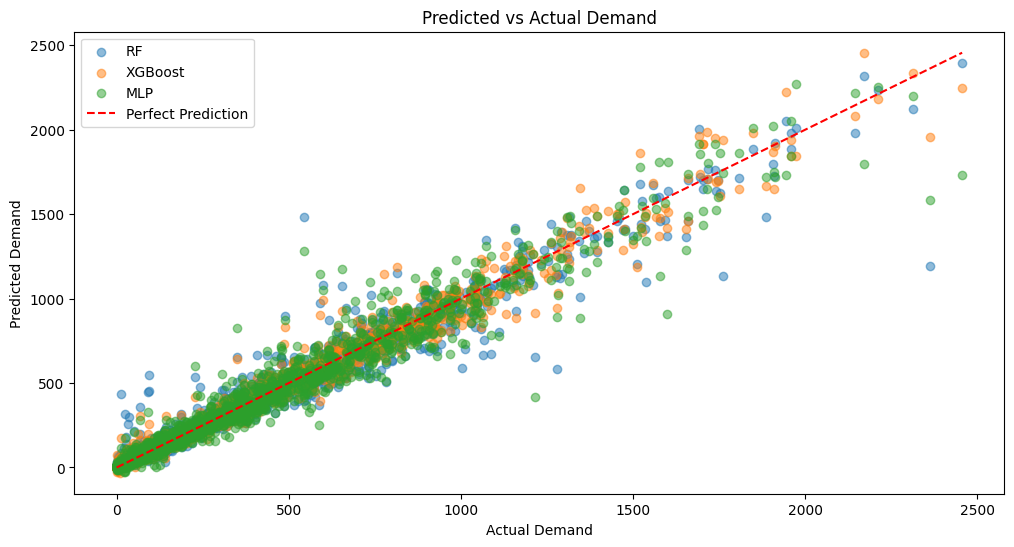

In [42]:
plt.figure(figsize=(12,6))
plt.scatter(y_test, best_rf_pred, alpha=0.5, label='RF')
plt.scatter(y_test, y_pred_xgb, alpha=0.5, label='XGBoost')
plt.scatter(y_test, y_pred_mlp, alpha=0.5, label='MLP')
plt.plot([0, y_test.max()], [0, y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.legend()
plt.title("Predicted vs Actual Demand")
plt.show()
#The closer the points are to the red diagonal line, the better the model.

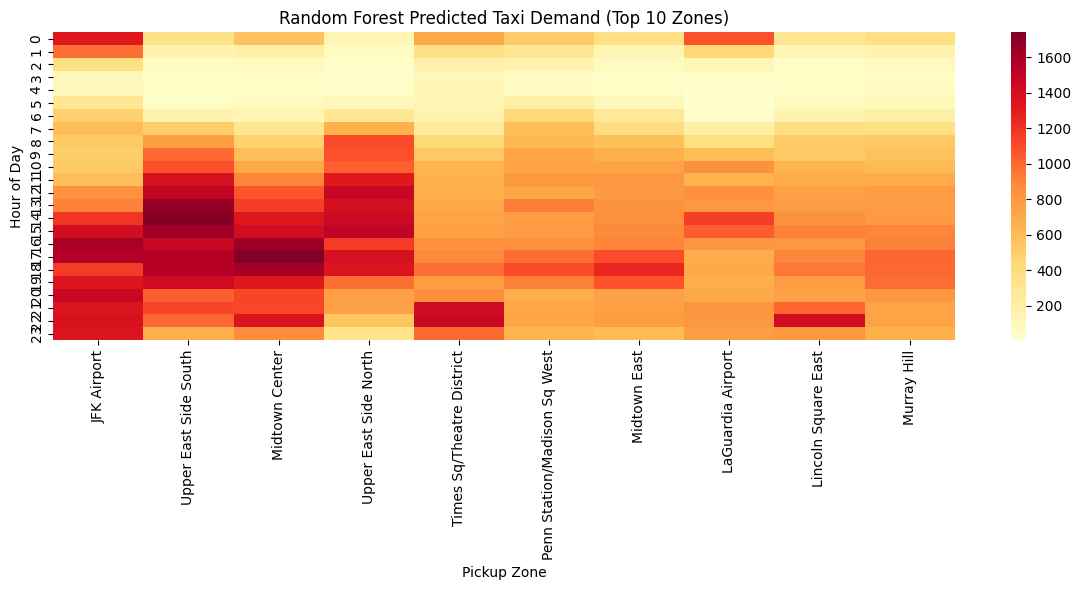

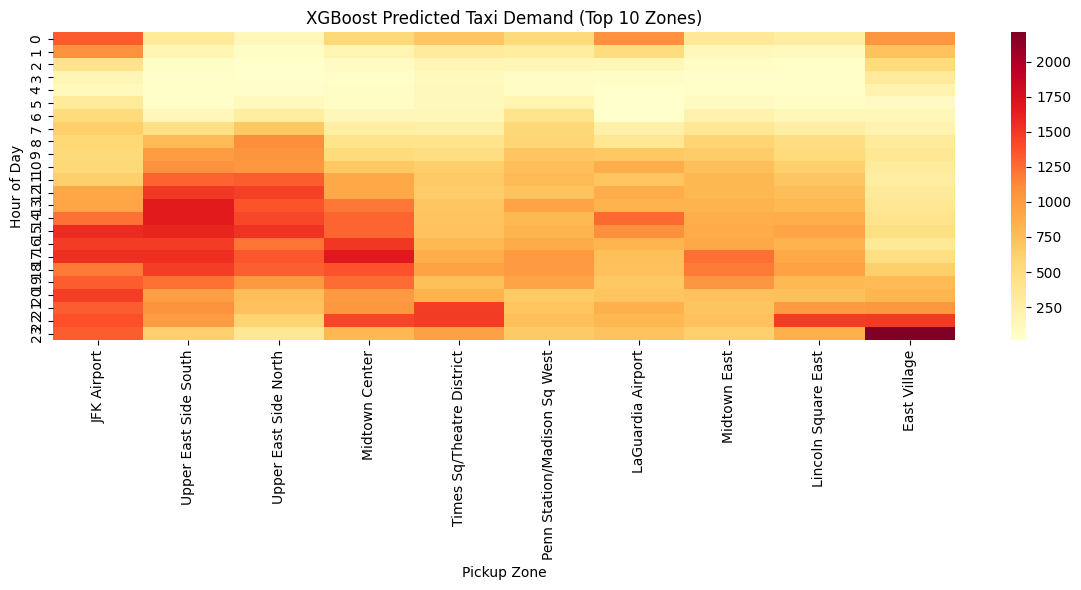

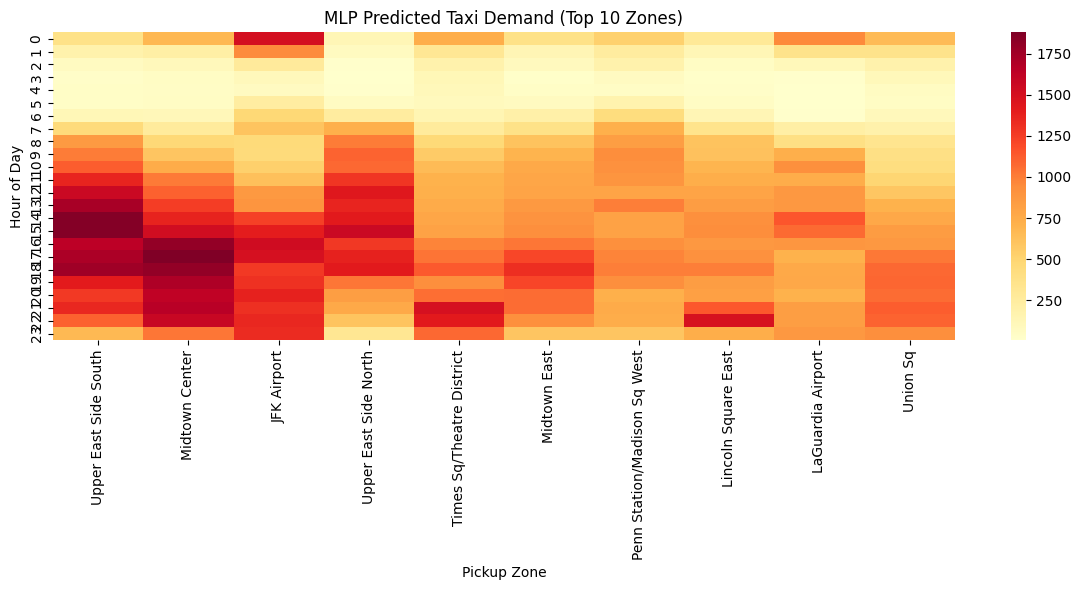

In [98]:
# 1.Prepare variables
hours = range(24)
zones_list = zones['LocationID'].tolist()  # All zone IDs
zone_names = zones.set_index('LocationID')['Zone'].to_dict()  # Map ID -> name

# Function to create prediction matrix for a given model
def create_pred_matrix(model):
    heatmap_matrix = np.zeros((24, len(zones_list)))
    for i, hour in enumerate(hours):
        all_zones_hour = pd.DataFrame({'PULocationID': zones_list})
        all_zones_hour['hour'] = hour
        all_zones_hour['day_of_week'] = 4  # Friday
        all_zones_hour = all_zones_hour.merge(
            demand[['PULocationID','hour','day_of_week','rolling_mean']],
            on=['PULocationID','hour','day_of_week'], how='left'
        )
        all_zones_hour['rolling_mean'] = all_zones_hour['rolling_mean'].fillna(demand['rolling_mean'].mean())

        # One-hot encode zones
        all_zones_enc = pd.get_dummies(all_zones_hour, columns=['PULocationID'])
        for col in X_train.columns:
            if col not in all_zones_enc.columns:
                all_zones_enc[col] = 0
        all_zones_enc = all_zones_enc[X_train.columns]

        # Predict demand
        preds = model.predict(all_zones_enc)
        heatmap_matrix[i, :] = preds

    return heatmap_matrix

# 2.Generate matrices
rf_matrix = create_pred_matrix(best_model)
xgb_matrix = create_pred_matrix(best_xgb)
mlp_matrix = create_pred_matrix(best_mlp)

# 3a.Function to get top N zones
def top_n_zones(matrix, n=10):
    total_demand = matrix.sum(axis=0)  # Sum over hours
    top_indices = np.argsort(total_demand)[-n:][::-1]  # Indices of top n zones
    return top_indices

# 3b.Plot heatmap for top N zones
def plot_top_heatmap(matrix, title, n=10):
    top_indices = top_n_zones(matrix, n)
    plt.figure(figsize=(12,6))
    sns.heatmap(matrix[:, top_indices], cmap="YlOrRd",
                xticklabels=[zone_names[zones_list[i]] for i in top_indices],
                yticklabels=hours)
    plt.xlabel("Pickup Zone")
    plt.ylabel("Hour of Day")
    plt.title(title)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

# 3c.Plot top 10 zones
plot_top_heatmap(rf_matrix, "Random Forest Predicted Taxi Demand (Top 10 Zones)")
plot_top_heatmap(xgb_matrix, "XGBoost Predicted Taxi Demand (Top 10 Zones)")
plot_top_heatmap(mlp_matrix, "MLP Predicted Taxi Demand (Top 10 Zones)")



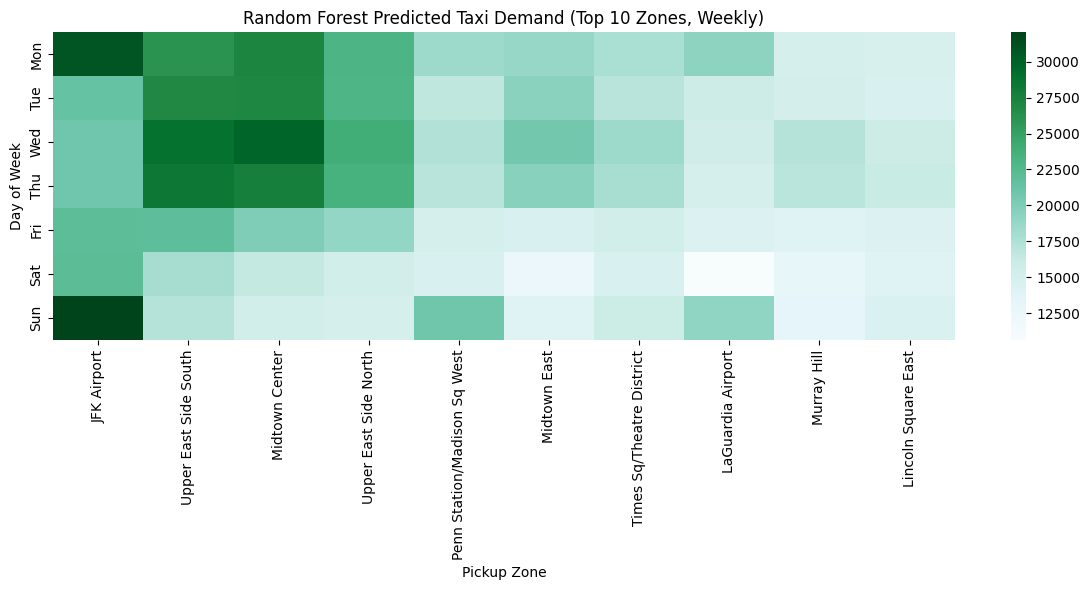

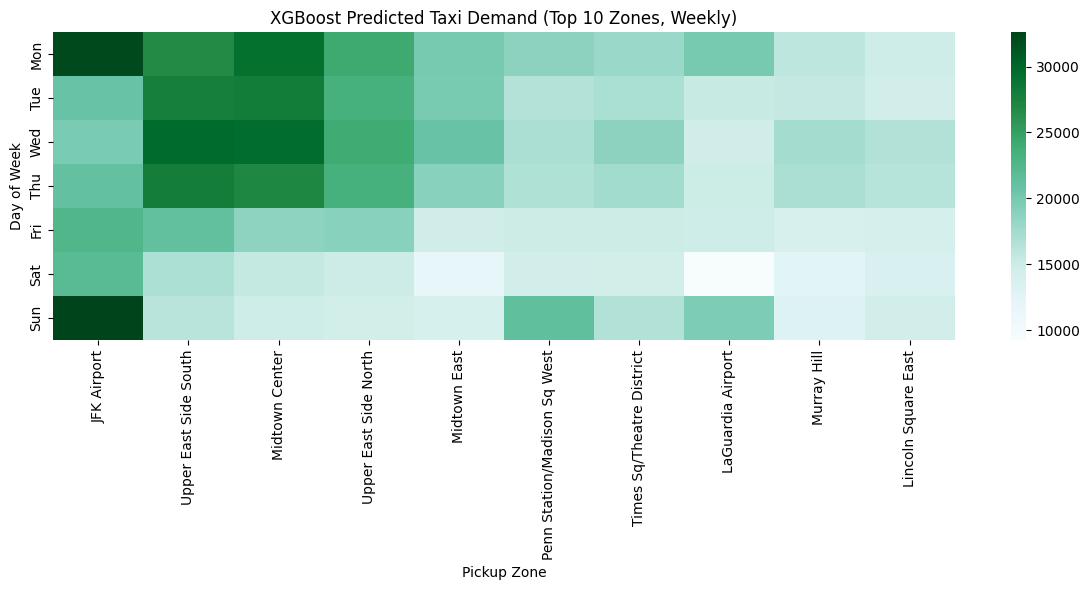

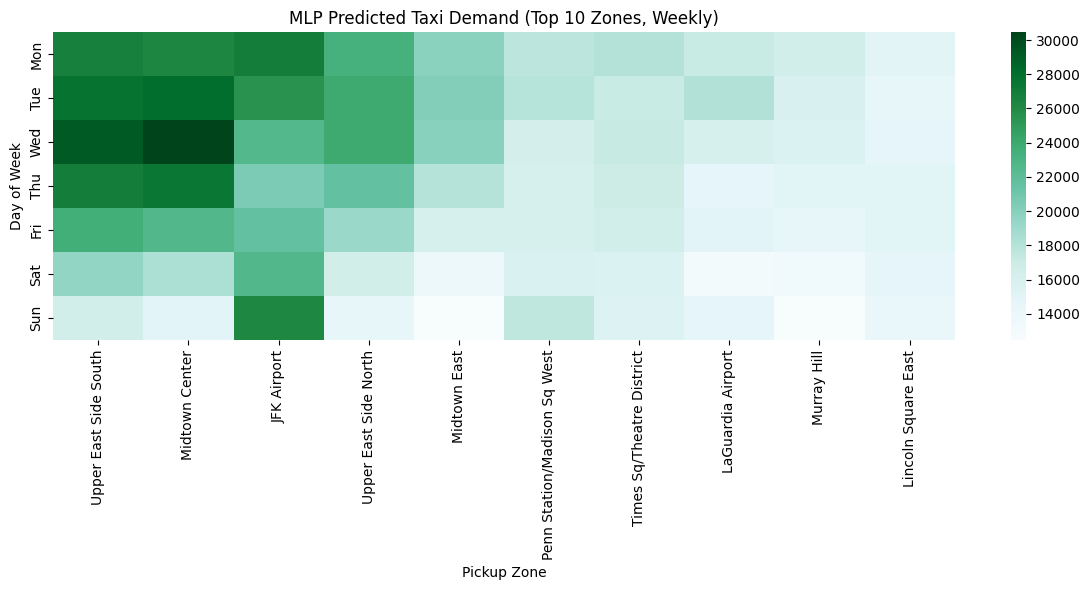

In [101]:
# 1.Prepare variables for weekly predictions
days = range(7)  # 0=Monday, 6=Sunday
zones_list = zones['LocationID'].tolist()
zone_names = zones.set_index('LocationID')['Zone'].to_dict()

# Function to create weekly prediction matrix
def create_weekly_pred_matrix(model):
    heatmap_matrix = np.zeros((7, len(zones_list)))  # rows=days, cols=zones
    for i, day in enumerate(days):
        for hour in hours:
            all_zones_hour = pd.DataFrame({'PULocationID': zones_list})
            all_zones_hour['hour'] = hour
            all_zones_hour['day_of_week'] = day
            all_zones_hour = all_zones_hour.merge(
                demand[['PULocationID','hour','day_of_week','rolling_mean']],
                on=['PULocationID','hour','day_of_week'], how='left'
            )
            all_zones_hour['rolling_mean'] = all_zones_hour['rolling_mean'].fillna(demand['rolling_mean'].mean())

            # One-hot encode zones
            all_zones_enc = pd.get_dummies(all_zones_hour, columns=['PULocationID'])
            for col in X_train.columns:
                if col not in all_zones_enc.columns:
                    all_zones_enc[col] = 0
            all_zones_enc = all_zones_enc[X_train.columns]

            # Predict and accumulate
            preds = model.predict(all_zones_enc)
            heatmap_matrix[i, :] += preds  # sum over hours

    return heatmap_matrix

# 2.Generate weekly matrices
rf_weekly = create_weekly_pred_matrix(best_model)
xgb_weekly = create_weekly_pred_matrix(best_xgb)
mlp_weekly = create_weekly_pred_matrix(best_mlp)

# 3.Plot heatmaps for top 10 zones weekly
def top_n_zones(matrix, n=10):
    total_demand = matrix.sum(axis=0)
    top_indices = np.argsort(total_demand)[-n:][::-1]
    return top_indices

def plot_top_weekly_heatmap(matrix, title, n=10):
    top_indices = top_n_zones(matrix, n)
    plt.figure(figsize=(12,6))
    sns.heatmap(matrix[:, top_indices], cmap="BuGn",
                xticklabels=[zone_names[zones_list[i]] for i in top_indices],
                yticklabels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
    plt.xlabel("Pickup Zone")
    plt.ylabel("Day of Week")
    plt.title(title)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

# 4.Plot weekly top 10 zones
plot_top_weekly_heatmap(rf_weekly, "Random Forest Predicted Taxi Demand (Top 10 Zones, Weekly)")
plot_top_weekly_heatmap(xgb_weekly, "XGBoost Predicted Taxi Demand (Top 10 Zones, Weekly)")
plot_top_weekly_heatmap(mlp_weekly, "MLP Predicted Taxi Demand (Top 10 Zones, Weekly)")


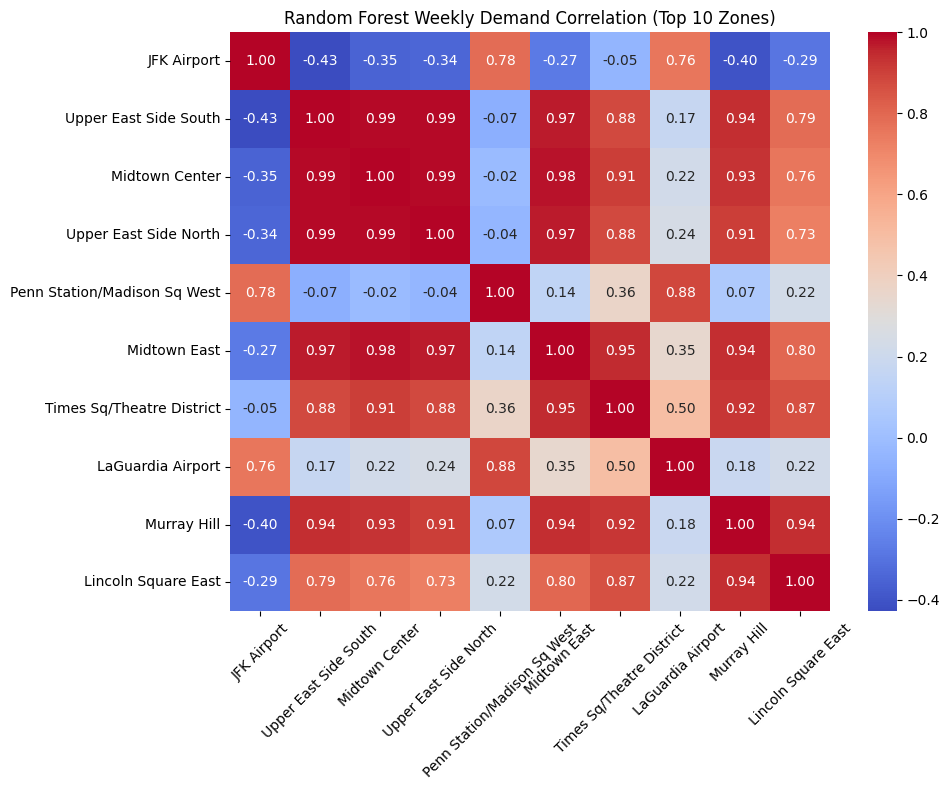

In [103]:
# 1.Get top 10 zones
top_indices = top_n_zones(rf_weekly, n=10)
top_zone_names = [zone_names[zones_list[i]] for i in top_indices]

# 2.Create DataFrame for top 10 zones
rf_weekly_top_df = pd.DataFrame(rf_weekly[:, top_indices], columns=top_zone_names)

# 3.Compute correlation matrix
rf_weekly_top_corr = rf_weekly_top_df.corr()

# 4.Plot correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(rf_weekly_top_corr, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Random Forest Weekly Demand Correlation (Top 10 Zones)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


                             Zone  predicted_demand  allocated_vehicles
228         Upper East Side North         73.079491                  56
178  Penn Station/Madison Sq West         54.301620                  42
134           Lincoln Square East         44.230175                  34
77                   East Village         29.748178                  23
231         Upper West Side South         28.843155                  22
255                Yorkville West         25.419579                  20
136           Little Italy/NoLiTa         25.775528                  20
130             LaGuardia Airport         25.014778                  19
223          TriBeCa/Civic Center         21.457321                  17
133               Lenox Hill West         20.337341                  16


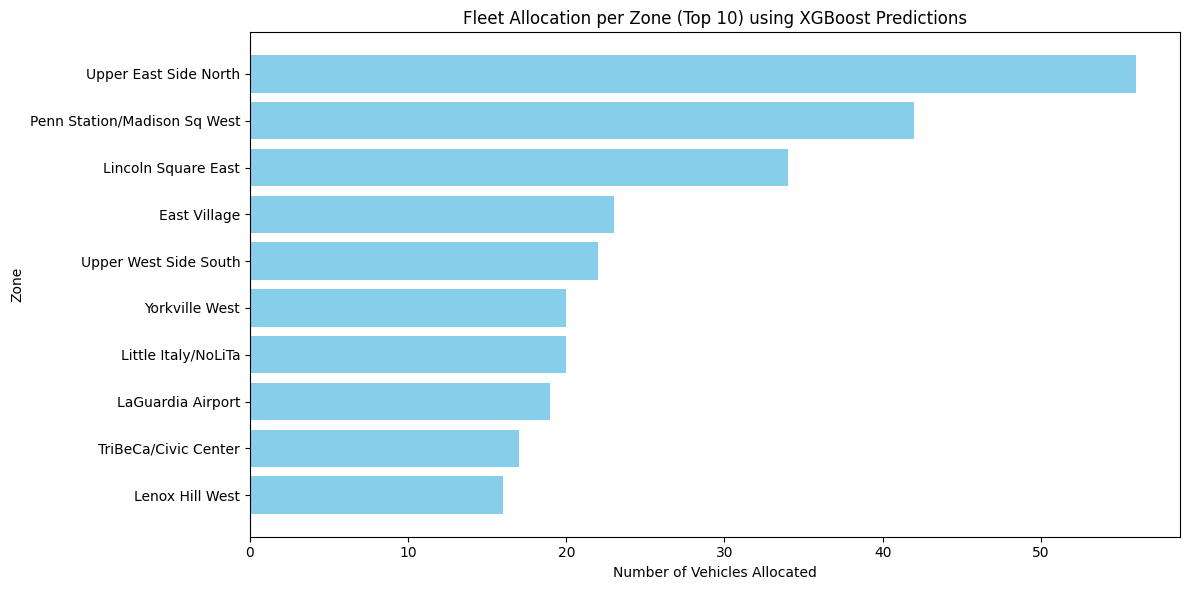

In [127]:
# Load lookup table (zones)
lookup_df = pd.read_csv(lookup_path)  # read the CSV into a DataFrame
all_zones = pd.DataFrame({
    'PULocationID': demand['PULocationID'].unique(),  # all pickup locations
    'hour': 18,                                       # hour of the day you are predicting
    'day_of_week': 4,                                 # day of the week you are predicting
    'rolling_mean': 0                                 # or any feature your model expects
})

# Predict demand using XGBoost 
def predict_demand(model, input_df):
    input_df = pd.DataFrame(input_df)  # ensure DataFrame
    
    # One-hot encode 'PULocationID' if exists
    if 'PULocationID' in input_df.columns:
        input_encoded = pd.get_dummies(input_df, columns=['PULocationID'])
    else:
        input_encoded = input_df.copy()
    
    # Ensure all columns from training exist
    input_encoded = input_encoded.reindex(columns=X_train.columns, fill_value=0)
    
    # Predict
    predictions = model.predict(input_encoded)
    
    input_df = input_df.copy()
    input_df['predicted_demand'] = predictions
    
    return input_df

# Predict demand
xgb_preds = predict_demand(best_xgb, all_zones)

# Merge with zone names
xgb_preds = xgb_preds.merge(
    lookup_df[['LocationID', 'Zone']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)

# Total vehicles available
total_vehicles = 500

# Compute proportion of demand
xgb_preds['demand_proportion'] = xgb_preds['predicted_demand'] / xgb_preds['predicted_demand'].sum()

# Allocate vehicles proportionally
xgb_preds['allocated_vehicles'] = (xgb_preds['demand_proportion'] * total_vehicles).round().astype(int)

# Select top 10 zones
top_zones = xgb_preds.sort_values('allocated_vehicles', ascending=False).head(10)

# Display table
print(top_zones[['Zone', 'predicted_demand', 'allocated_vehicles']])

# Plot top 10 zones
plt.figure(figsize=(12,6))
plt.barh(top_zones['Zone'], top_zones['allocated_vehicles'], color='skyblue')
plt.xlabel("Number of Vehicles Allocated")
plt.ylabel("Zone")
plt.title("Fleet Allocation per Zone (Top 10) using XGBoost Predictions")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


                             Zone  predicted_demand  allocated_vehicles  \
228         Upper East Side North         73.079491                  56   
178  Penn Station/Madison Sq West         54.301620                  42   
134           Lincoln Square East         44.230175                  34   
77                   East Village         29.748178                  23   
231         Upper West Side South         28.843155                  22   
255                Yorkville West         25.419579                  20   
136           Little Italy/NoLiTa         25.775528                  20   
130             LaGuardia Airport         25.014778                  19   
223          TriBeCa/Civic Center         21.457321                  17   
133               Lenox Hill West         20.337341                  16   

     surge_factor  surge_price  
228      1.152495    24.025038  
178      1.146448    28.276573  
134      1.150444    24.949075  
77       1.146700    25.810311  
231      

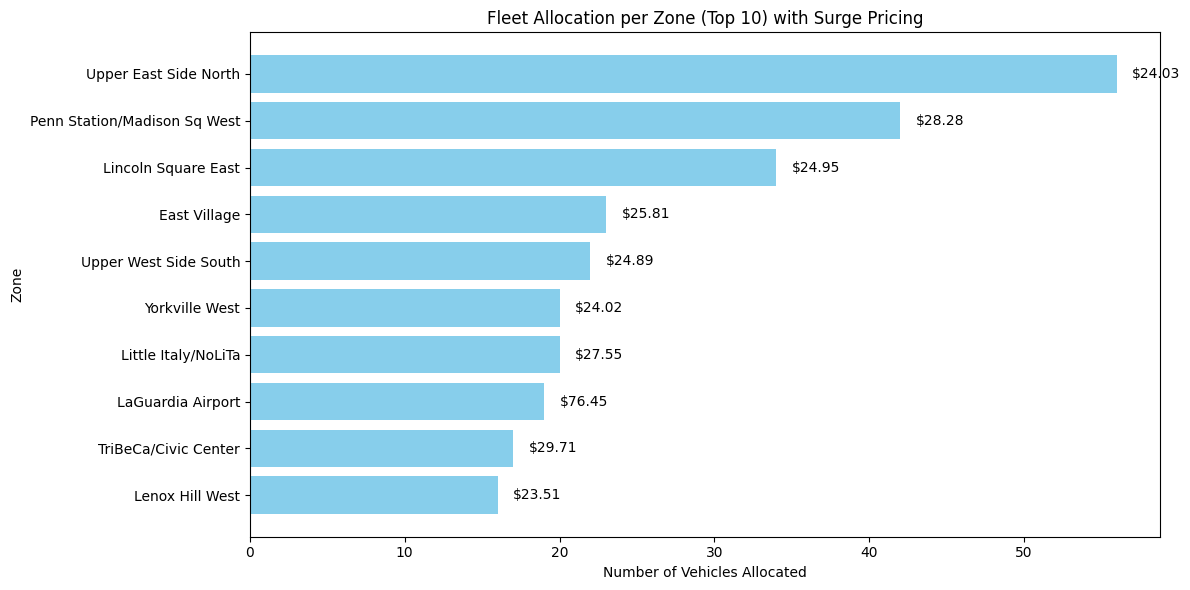

In [145]:
# 1.Load lookup table for zones 
lookup_df = pd.read_csv(lookup_path)  # CSV with LocationID, Zone

# 2.Load trips dataset (contains total_amount) 
# Correct way to read a Parquet file
trips_df = pd.read_parquet(parquet_path)  # parquet_path is your Parquet file
 # replace with your trips file
# Compute average fare per pickup zone
avg_fare_per_zone = trips_df.groupby('PULocationID')['total_amount'].mean().reset_index()
avg_fare_per_zone.rename(columns={'total_amount':'avg_total_amount'}, inplace=True)

# 3.Predict demand function 
def predict_demand(model, input_df):
    input_df = pd.DataFrame(input_df)
    
    if 'PULocationID' in input_df.columns:
        input_encoded = pd.get_dummies(input_df, columns=['PULocationID'])
    else:
        input_encoded = input_df.copy()
    
    input_encoded = input_encoded.reindex(columns=X_train.columns, fill_value=0)
    predictions = model.predict(input_encoded)
    
    input_df = input_df.copy()
    input_df['predicted_demand'] = predictions
    return input_df

# 4.Prepare all zones DataFrame 
all_zones = pd.DataFrame({
    'PULocationID': demand['PULocationID'].unique(),
    'hour': 18,
    'day_of_week': 4,
    'rolling_mean': 0
})

# 5.Predict demand 
xgb_preds = predict_demand(best_xgb, all_zones)

# 6.Merge with zone names 
xgb_preds = xgb_preds.merge(
    lookup_df[['LocationID', 'Zone']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)

# 7.Merge with average total_amount from trips dataset 
xgb_preds = xgb_preds.merge(avg_fare_per_zone, on='PULocationID', how='left')

# 8️.Allocate vehicles proportionally 
total_vehicles = 500
xgb_preds['demand_proportion'] = xgb_preds['predicted_demand'] / xgb_preds['predicted_demand'].sum()
xgb_preds['allocated_vehicles'] = (xgb_preds['demand_proportion'] * total_vehicles).round().astype(int)

# 9️.Compute surge factor 
alpha = 0.5
min_allocated = 1  # avoid division by zero
xgb_preds['shortage_ratio'] = (xgb_preds['predicted_demand'] - xgb_preds['allocated_vehicles']) / \
                              xgb_preds['allocated_vehicles'].replace(0, min_allocated)
xgb_preds['shortage_ratio'] = xgb_preds['shortage_ratio'].apply(lambda x: max(0, x))
xgb_preds['surge_factor'] = 1 + alpha * xgb_preds['shortage_ratio']

# 10.Compute surge price using actual total_amount 
xgb_preds['surge_price'] = xgb_preds['avg_total_amount'] * xgb_preds['surge_factor']

# 11.Select top 10 zones by allocated vehicles 
top_zones = xgb_preds.sort_values('allocated_vehicles', ascending=False).head(10)

# Display top zones
print(top_zones[['Zone', 'predicted_demand', 'allocated_vehicles', 'surge_factor', 'surge_price']])

# 12.Plot top 10 zones 
plt.figure(figsize=(12,6))
bars = plt.barh(top_zones['Zone'], top_zones['allocated_vehicles'], color='skyblue')
plt.xlabel("Number of Vehicles Allocated")
plt.ylabel("Zone")
plt.title("Fleet Allocation per Zone (Top 10) with Surge Pricing")

# Add surge price labels on bars
for bar, surge in zip(bars, top_zones['surge_price']):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f"${surge:.2f}", va='center')

plt.gca().invert_yaxis()  # largest allocation on top
plt.tight_layout()
plt.show()
